In [73]:
import time

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, MCMC, NUTS
from pyro.infer.autoguide import (
    AutoDiagonalNormal,
    AutoMultivariateNormal,
    init_to_median,
    init_to_value,
)

from sklearn.cluster import KMeans
import arviz as az

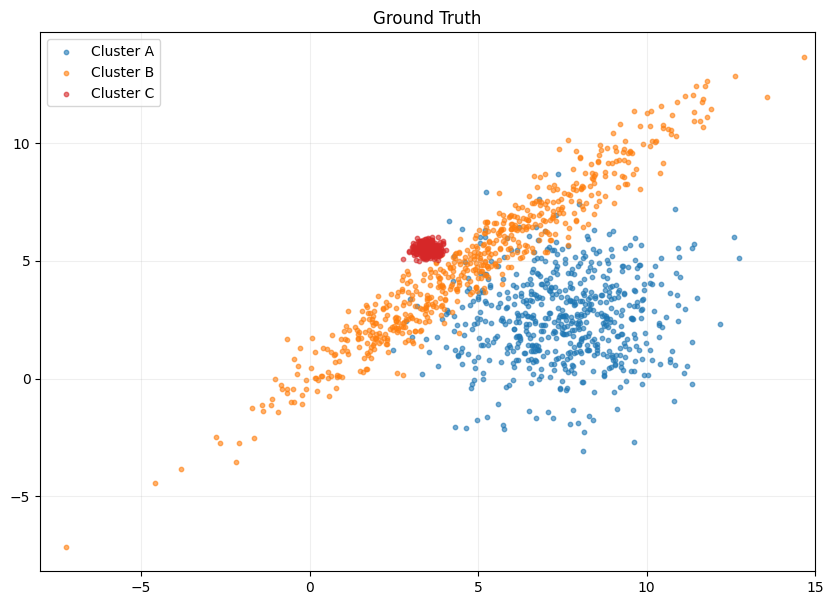

In [74]:
def generate_complex_gmm_data_with_labels(n_samples=1500):
    torch.manual_seed(42)

    # 1) Кластер A: широкий (n=600)
    loc_a = torch.tensor([7.5, 2.5])
    data_a = torch.randn(600, 2) * 1.8 + loc_a
    labels_a = torch.zeros(600)

    # 2) Кластер B: вытянутый по диагонали (n=600)
    loc_b = torch.tensor([5.0, 5.0])
    scale_b = torch.tensor([4.5, 0.6])
    theta = torch.tensor([torch.pi / 4])  # 45 градусов
    rot = torch.tensor([[theta.cos(), -theta.sin()], [theta.sin(), theta.cos()]])
    data_b = (torch.randn(600, 2) * scale_b) @ rot.T + loc_b
    labels_b = torch.ones(600)

    # 3) Кластер C: узкий пик рядом с B (n=300)
    loc_c = torch.tensor([3.5, 5.5])
    data_c = torch.randn(300, 2) * 0.2 + loc_c
    labels_c = torch.ones(300) * 2

    # Объединение
    data = torch.cat([data_a, data_b, data_c])
    labels = torch.cat([labels_a, labels_b, labels_c])
    # Перемешивание с сохранением соответствия меток
    idx = torch.randperm(n_samples)
    return data[idx], labels[idx]


data_2d, true_labels = generate_complex_gmm_data_with_labels()

plt.figure(figsize=(10, 7))
colors = ['#1f77b4', '#ff7f0e', '#d62728']
for i, lbl in enumerate(['A', 'B', 'C']):
    mask = (true_labels == i)
    plt.scatter(data_2d[mask, 0], data_2d[mask, 1], 
                s=10, alpha=0.6, c=colors[i], label=f'Cluster {lbl}')


plt.title("Ground Truth")
plt.legend()
#plt.axis('equal')
plt.xlim(-8, 15)
plt.grid(True, alpha=0.2)
plt.show()

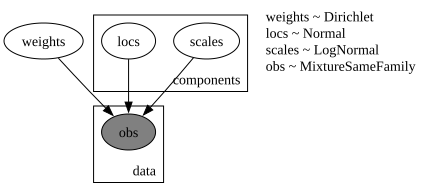

In [75]:
def model_mf(data, K=3):
    D = data.shape[1]  # Размерность данных
    # Dirichlet(1.0) равномерное распределение весов компонентов смеси
    weights = pyro.sample("weights", dist.Dirichlet(torch.ones(K)))
    with pyro.plate("components", K):
        # Средние для каждого кластера
        locs = pyro.sample("locs", dist.Normal(torch.zeros(D), 1.0).to_event(1))
        # Масштабы для каждого кластера
        scales = pyro.sample("scales", dist.LogNormal(torch.zeros(D), 1.0).to_event(1))

    mixing_dist = dist.Categorical(weights)
    # Объединение компонентов в одну смесь
    component_dist = dist.Normal(locs, scales).to_event(1)
    mixture = dist.MixtureSameFamily(mixing_dist, component_dist)
    
    with pyro.plate("data", len(data)):
        pyro.sample("obs", mixture, obs=data)


pyro.render_model(model_mf, model_args=(data_2d,), render_distributions=True)

Я создаю variational guide для Basic VI (AutoDiagonalNormal) с инициализацией init_to_median.


In [76]:
from pyro.infer.autoguide import AutoDiagonalNormal, init_to_median

pyro.clear_param_store()

guide = AutoDiagonalNormal(model_mf, init_loc_fn=init_to_median)

Я запускаю SVI для Basic VI и собираю ELBO loss по итерациям + время обучения.


In [77]:
adam = pyro.optim.Adam({"lr": 0.01})
svi = SVI(model_mf, guide, adam, loss=Trace_ELBO())

# Цикл обучения
n_steps = 2000
losses = []

start_time = time.time()
for step in range(n_steps):
    loss = svi.step(data_2d)
    losses.append(loss)
    if step % 500 == 0:
        print(f"Step {step} - Loss: {loss:.2f}")

duration = time.time() - start_time
print(f"Обучение завершено за {duration:.2f} сек.")

Step 0 - Loss: 72605.22
Step 500 - Loss: 8945.06
Step 1000 - Loss: 8177.55
Step 1500 - Loss: 7646.40
Обучение завершено за 9.68 сек.


Визуализирую динамику ELBO loss, чтобы убедиться, что 2000 итераций достаточно.


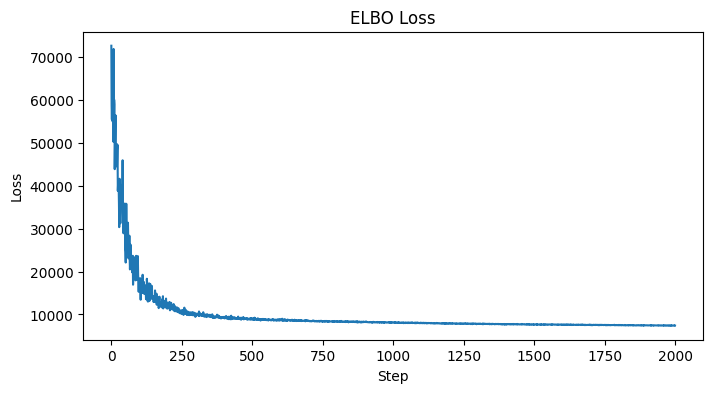

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.title("ELBO Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.show()

Извлекаю median-параметры из guide (центры и масштабы), чтобы потом рисовать эллипсы.


In [79]:
with torch.no_grad():
    medians = guide.median()
    final_locs = medians['locs']
    final_scales = medians['scales']

Рисую 2-sigma эллипсы по median-параметрам Basic VI поверх данных.


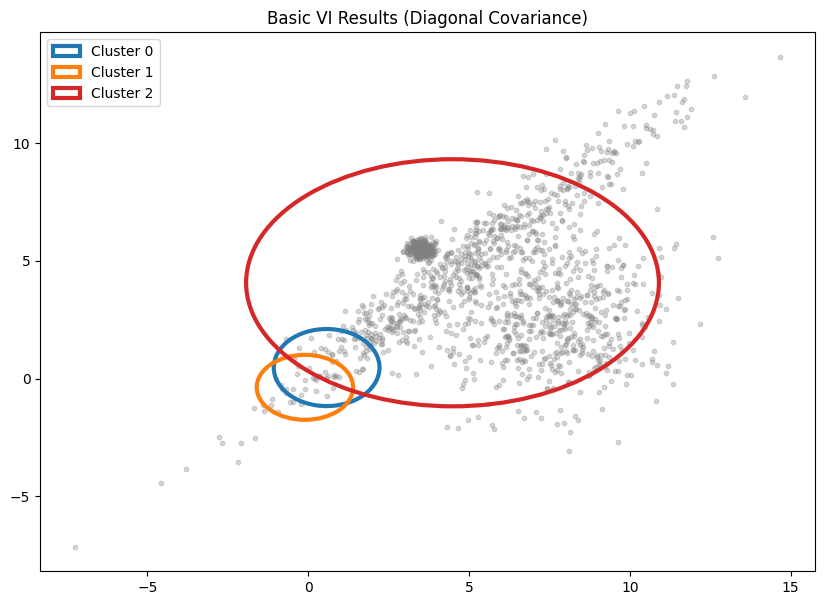

In [ ]:
from matplotlib.patches import Ellipse

def plot_results(data, locs, scales, title):
    plt.figure(figsize=(10, 7))
    plt.scatter(data[:, 0], data[:, 1], s=10, alpha=0.3, c='gray')
    
    ax = plt.gca()
    for i in range(len(locs)):
        # Эллипс 2-sigma (накрывает ~95% данных)
        # width и height диаметры, поэтому умножаю scale на 2 для sigma и на 2 жля диаметра = 4
        el = Ellipse(xy=locs[i], width=4*scales[i, 0], height=4*scales[i, 1], 
                     angle=0, color=colors[i], fill=False, linewidth=3, label=f'Cluster {i}')
        ax.add_patch(el)
        
    plt.title(title)
    plt.legend()
    plt.show()

plot_results(data_2d, final_locs, final_scales, "Basic VI Results (Diagonal Covariance)")

Делаю K-means инициализацию (эмпирический Байес) для Basic VI, беру центры кластеров как init для locs.


In [99]:
km = KMeans(n_clusters=3, n_init=10).fit(data_2d.numpy())
km_centers = torch.tensor(km.cluster_centers_, dtype=torch.float)

def init_loc_fn(site):
    if site["name"] == "locs":
        return km_centers
    if site["name"] == "scales":
        shape = site["fn"].batch_shape + site["fn"].event_shape
        return torch.ones(shape, device=km_centers.device)
    return init_to_median(site)

pyro.clear_param_store()
guide_km = AutoDiagonalNormal(model_mf, init_loc_fn=init_loc_fn)

Повторно запускаю SVI для Basic VI с KMeans-инициализированным guide и сравниваю с init_to_median.


In [100]:
adam = pyro.optim.Adam({"lr": 0.01})
svi = SVI(model_mf, guide_km, adam, loss=Trace_ELBO())

n_steps = 2000
losses = []
start_time = time.time()

for step in range(n_steps):
    loss = svi.step(data_2d)
    losses.append(loss)
    if step % 500 == 0:
        print(f"Step {step} - Loss: {loss:.2f}")

duration = time.time() - start_time
print(f"Обучение завершено за {duration:.2f} сек.")

Step 0 - Loss: 8757.77
Step 500 - Loss: 7251.62
Step 1000 - Loss: 7247.54
Step 1500 - Loss: 7248.75
Обучение завершено за 9.21 сек.


Я визуализирую результат Basic VI после KMeans-init: эллипсы 2-sigma поверх исходных данных.


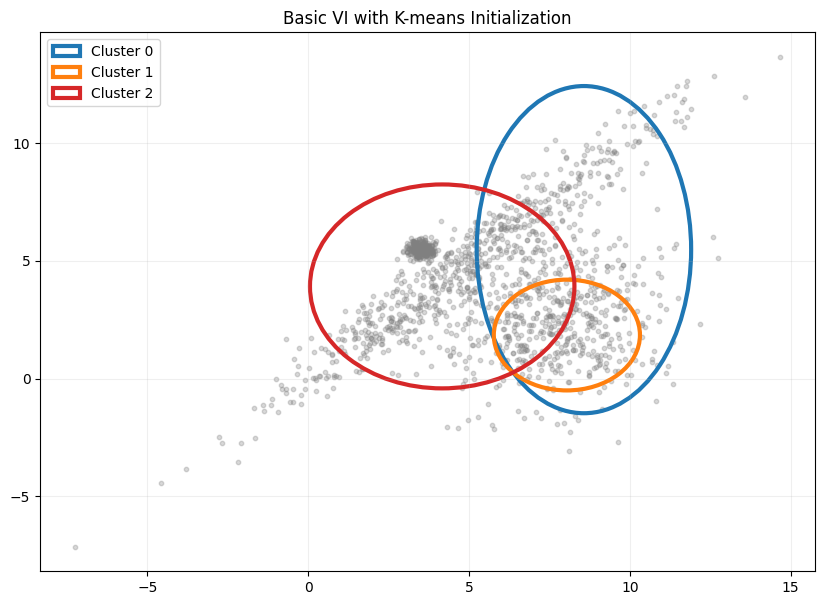

In [101]:
import torch
from matplotlib.patches import Ellipse

with torch.no_grad():
    medians = guide_km.median()
    final_locs = medians['locs']
    final_scales = medians['scales']

plt.figure(figsize=(10, 7))
plt.scatter(data_2d[:, 0], data_2d[:, 1], s=10, alpha=0.3, c='gray')
ax = plt.gca()

colors = ['#1f77b4', '#ff7f0e', '#d62728']
for i in range(len(final_locs)):
    el = Ellipse(xy=final_locs[i], width=4*final_scales[i, 0], height=4*final_scales[i, 1], 
                 angle=0, color=colors[i], fill=False, linewidth=3, label=f'Cluster {i}')
    ax.add_patch(el)

plt.title("Basic VI with K-means Initialization")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

Задаю "универсальную" full-rank модель GMM (полная ковариация через LKJCholesky), чтобы использовать её в Full Rank VI и MCMC.


In [102]:
import pyro.distributions as dist

def model_full(data, K=3):
    D = data.shape[1]
    weights = pyro.sample("weights", dist.Dirichlet(torch.ones(K)))
    
    with pyro.plate("components", K):
        # Средние
        locs = pyro.sample("locs", dist.Normal(torch.zeros(D), 10.).to_event(1))
        # Работа с матрицей ковариации через разложение Холецкого
        scales = pyro.sample("scales", dist.HalfNormal(torch.ones(D)).to_event(1))
        corr_cholesky = pyro.sample("corr_cholesky", dist.LKJCholesky(D, eta=1.0))
        L_omega = torch.diag_embed(scales) @ corr_cholesky
    # Смесь с MultivariateNormal
    mixing_dist = dist.Categorical(weights)
    component_dist = dist.MultivariateNormal(locs, scale_tril=L_omega)
    mixture = dist.MixtureSameFamily(mixing_dist, component_dist)
    
    with pyro.plate("data", len(data)):
        pyro.sample("obs", mixture, obs=data)

# Full Rank гайд
from pyro.infer.autoguide import AutoMultivariateNormal

pyro.clear_param_store()
# Та же K-means инициализацию, что и раньше
guide_full = AutoMultivariateNormal(model_full, init_loc_fn=init_loc_fn)

Запуск Full Rank VI (AutoMultivariateNormal) для full-rank модели, обучаю SVI, строю loss и эллипсы 2-sigma.


Начинаем обучение Full Rank VI...
Step 0 - Loss: 8779.80
Step 500 - Loss: 6757.82
Step 1000 - Loss: 6438.60
Step 1500 - Loss: 6057.24
Обучение завершено за 14.74 сек.


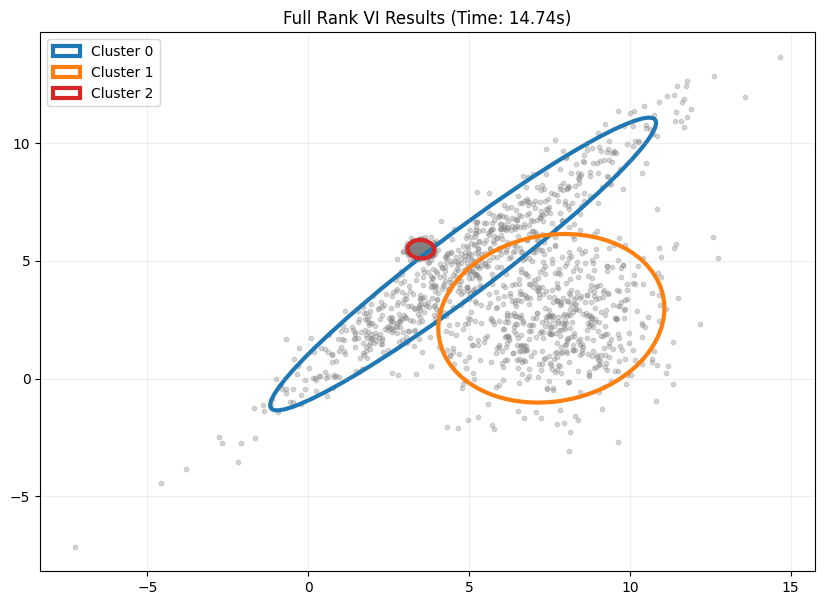

In [103]:
import torch
import pyro
import pyro.distributions as dist
import time
from pyro.infer import SVI, Trace_ELBO
from pyro.infer.autoguide import AutoMultivariateNormal
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import numpy as np

def model_full(data, K=3):
    D = data.shape[1]
    weights = pyro.sample("weights", dist.Dirichlet(torch.ones(K)))
    
    with pyro.plate("components", K):
        locs = pyro.sample("locs", dist.Normal(torch.zeros(D), 10.0).to_event(1))
        scales = pyro.sample("scales", dist.HalfNormal(torch.ones(D)).to_event(1))
        corr_cholesky = pyro.sample("corr_cholesky", dist.LKJCholesky(D, concentration=torch.tensor(1.0)))
        L_omega = torch.diag_embed(scales) @ corr_cholesky

    mixing_dist = dist.Categorical(weights)
    component_dist = dist.MultivariateNormal(locs, scale_tril=L_omega)
    mixture = dist.MixtureSameFamily(mixing_dist, component_dist)
    
    with pyro.plate("data", len(data)):
        pyro.sample("obs", mixture, obs=data)

# Подготовка обучения
pyro.clear_param_store()
guide_full = AutoMultivariateNormal(model_full, init_loc_fn=init_loc_fn)

adam = pyro.optim.Adam({"lr": 0.01})
svi = SVI(model_full, guide_full, adam, loss=Trace_ELBO())

# Циклы обучения
n_steps = 2000
losses_full = []

print("Начинаем обучение Full Rank VI...")
start_time = time.time()

for step in range(n_steps):
    loss = svi.step(data_2d)
    losses_full.append(loss)
    if step % 500 == 0:
        print(f"Step {step} - Loss: {loss:.2f}")

duration_full = time.time() - start_time
print(f"Обучение завершено за {duration_full:.2f} сек.")

# Визуализация результата
def plot_full_rank_results(data, guide):
    with torch.no_grad():
        medians = guide.median()
        locs = medians['locs'].numpy()
        scales = medians['scales'].numpy()
        corr_cholesky = medians['corr_cholesky'].numpy()
        
    plt.figure(figsize=(10, 7))
    plt.scatter(data[:, 0], data[:, 1], s=10, alpha=0.3, c='gray')
    ax = plt.gca()
    colors = ['#1f77b4', '#ff7f0e', '#d62728']
    
    for i in range(len(locs)):
        # Матрица ковариации Sigma = L 
        L = np.diag(scales[i]) @ corr_cholesky[i]
        cov = L @ L.T
        
        # Форма эллипса
        vals, vecs = np.linalg.eigh(cov)
        order = vals.argsort()[::-1]
        vals, vecs = vals[order], vecs[:, order]
        theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
        width, height = 4 * np.sqrt(vals) 
        
        el = Ellipse(xy=locs[i], width=width, height=height, angle=theta,
                     edgecolor=colors[i], fill=False, linewidth=3, label=f'Cluster {i}')
        ax.add_patch(el)

    plt.title(f"Full Rank VI Results (Time: {duration_full:.2f}s)")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

plot_full_rank_results(data_2d, guide_full)

Задаю модель для MCMC/NUTS (универсальная GMM с полной ковариацией), чтобы сравнить VI и MCMC.


In [104]:
from pyro.infer import MCMC, NUTS

def model_mcmc(data, K=3):
    D = data.shape[1]
    weights = pyro.sample("weights", dist.Dirichlet(torch.ones(K)))
    
    with pyro.plate("components", K):
        locs = pyro.sample("locs", dist.Normal(torch.zeros(D), 10.0).to_event(1))
        scales = pyro.sample("scales", dist.HalfNormal(torch.ones(D)).to_event(1))
        corr_cholesky = pyro.sample("corr_cholesky", dist.LKJCholesky(D, concentration=1.0))
        L_omega = torch.diag_embed(scales) @ corr_cholesky

    component_dist = dist.MultivariateNormal(locs, scale_tril=L_omega)
    mixture = dist.MixtureSameFamily(dist.Categorical(weights), component_dist)
    
    with pyro.plate("data", len(data)):
        pyro.sample("obs", mixture, obs=data)

Запускаю NUTS/MCMC для двух warmup (20 и 100) и измеряю время работы.


In [105]:
def run_mcmc(warmup, num_samples=300):
    pyro.clear_param_store()
    nuts_kernel = NUTS(model_mcmc)
    mcmc = MCMC(nuts_kernel, num_samples=num_samples, warmup_steps=warmup)
    
    start_time = time.time()
    mcmc.run(data_2d)
    duration = time.time() - start_time
    
    print(f"MCMC ({warmup} warmup) завершен за {duration:.2f} сек.")
    return mcmc, duration

mcmc_20, time_20 = run_mcmc(20)
mcmc_100, time_100 = run_mcmc(100)

Sample: 100%|██████████| 320/320 [00:13, 23.05it/s, step size=7.75e-02, acc. prob=0.082]


MCMC (20 warmup) завершен за 13.89 сек.


Sample: 100%|██████████| 400/400 [01:59,  3.34it/s, step size=1.53e-02, acc. prob=0.953]

MCMC (100 warmup) завершен за 119.79 сек.


Подклюбчаю ArviZ и строю диагностики MCMC trace plots, R-hat summary, autocorrelation.


c:\Users\Piligrim\AppData\Local\Programs\Python\Python312\Lib\site-packages\arviz\data\io_pyro.py:158: UserWarning: Could not get vectorized trace, log_likelihood group will be omitted. Check your model vectorization or set log_likelihood=False
  warnings.warn(


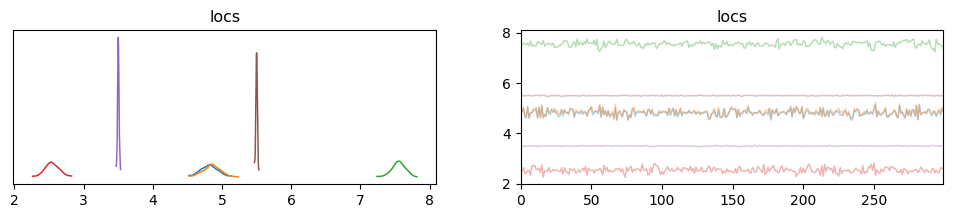

arviz - WARNING - Shape validation failed: input_shape: (1, 300), minimum_shape: (chains=2, draws=4)


             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
locs[0, 0]  4.816  0.123   4.589    5.034      0.005    0.006     543.0   
locs[0, 1]  4.854  0.126   4.627    5.086      0.006    0.007     490.0   
locs[1, 0]  7.552  0.098   7.364    7.735      0.008    0.006     165.0   
locs[1, 1]  2.545  0.102   2.350    2.730      0.006    0.005     300.0   
locs[2, 0]  3.502  0.011   3.484    3.528      0.001    0.001     258.0   
locs[2, 1]  5.501  0.012   5.479    5.523      0.001    0.001     396.0   
weights[0]  0.406  0.016   0.374    0.435      0.001    0.001     213.0   
weights[1]  0.395  0.016   0.367    0.426      0.001    0.001     256.0   
weights[2]  0.199  0.010   0.183    0.218      0.000    0.001     449.0   

            ess_tail  r_hat  
locs[0, 0]     249.0    NaN  
locs[0, 1]     222.0    NaN  
locs[1, 0]     167.0    NaN  
locs[1, 1]     282.0    NaN  
locs[2, 0]     208.0    NaN  
locs[2, 1]     135.0    NaN  
weights[0]     221.0    NaN  
weights[1

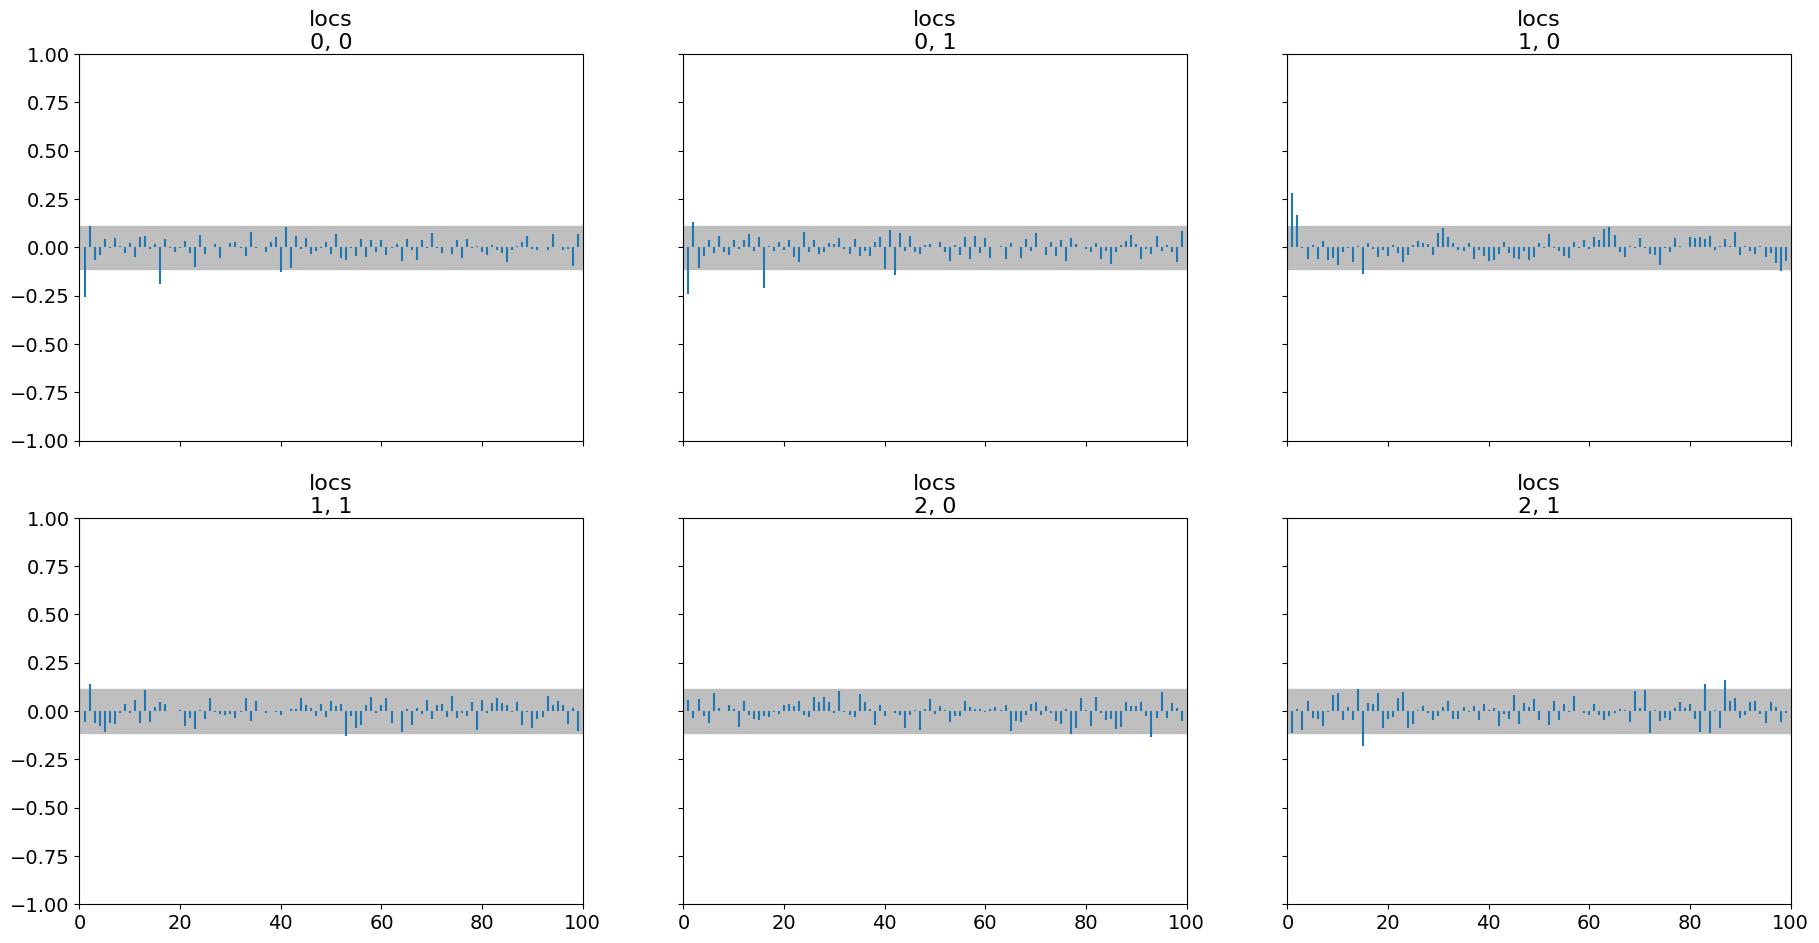

In [106]:
import arviz as az

# Конвертирую данные Pyro в формат ArviZ
data_az_20 = az.from_pyro(mcmc_20)
data_az_100 = az.from_pyro(mcmc_100)

az.plot_trace(data_az_100, var_names=["locs"])
plt.show()

print(az.summary(data_az_100, var_names=["locs", "weights"]))

az.plot_autocorr(data_az_100, var_names=["locs"], combined=True)
plt.show()

Беру MCMC-сэмплы и усредняю параметры (для последующей визуализации/понимания результата).


In [89]:
samples = mcmc_100.get_samples()
mean_locs = samples['locs'].mean(0)
mean_scales = samples['scales'].mean(0)
mean_corr = samples['corr_cholesky'].mean(0)

Определяю функцию, которая рисует MCMC-результат (2-sigma эллипсы по средним параметрам выборки).


In [107]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

def plot_mcmc_results(data, mcmc_obj, title="MCMC Results"):
    samples = mcmc_obj.get_samples()
    
    with torch.no_grad():
        locs = samples['locs'].mean(0).numpy()        
        scales = samples['scales'].mean(0).numpy()   
        corr_cholesky = samples['corr_cholesky'].mean(0).numpy() 

    plt.figure(figsize=(10, 7))
    plt.scatter(data[:, 0], data[:, 1], s=10, alpha=0.3, c='gray')
    ax = plt.gca()
    colors = ['#1f77b4', '#ff7f0e', '#d62728']
    
    for i in range(len(locs)):
        # Восстанавливаю матрицу ковариации из средних значений
        L = np.diag(scales[i]) @ corr_cholesky[i]
        cov = L @ L.T
        
        # Считаю геометрию эллипса
        vals, vecs = np.linalg.eigh(cov)
        order = vals.argsort()[::-1]
        vals, vecs = vals[order], vecs[:, order]
        theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
        width, height = 4 * np.sqrt(vals) # 2-sigma
        
        el = Ellipse(xy=locs[i], width=width, height=height, angle=theta,
                     edgecolor=colors[i], fill=False, linewidth=3, label=f'Cluster {i}')
        ax.add_patch(el)

    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

Я запускаю NUTS/MCMC для full-rank модели при warmup=20 и warmup=100 и сравниваю результаты.


Запуск MCMC (warmup=20)...


Sample: 100%|██████████| 320/320 [00:11, 27.04it/s, step size=1.10e-01, acc. prob=0.010]


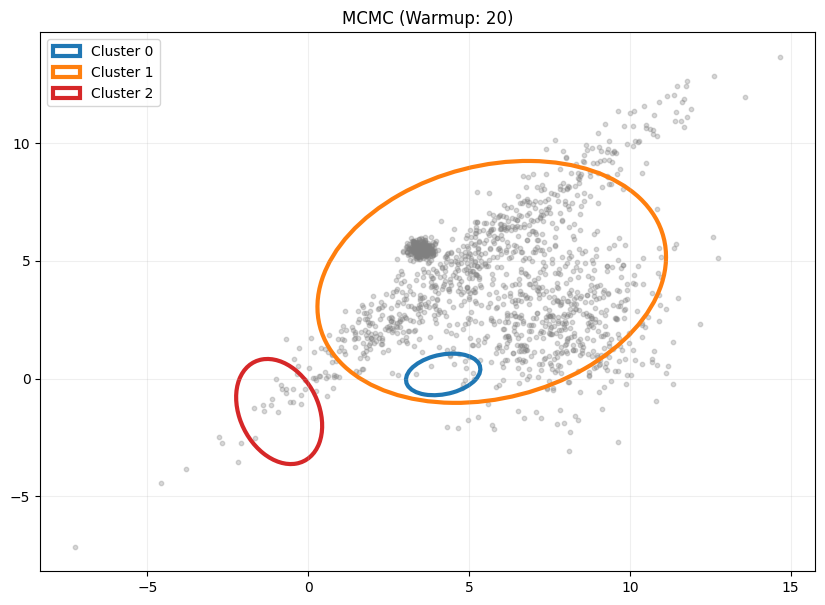

Запуск MCMC (warmup=100)...


Sample: 100%|██████████| 400/400 [01:52,  3.55it/s, step size=1.14e-02, acc. prob=0.868]


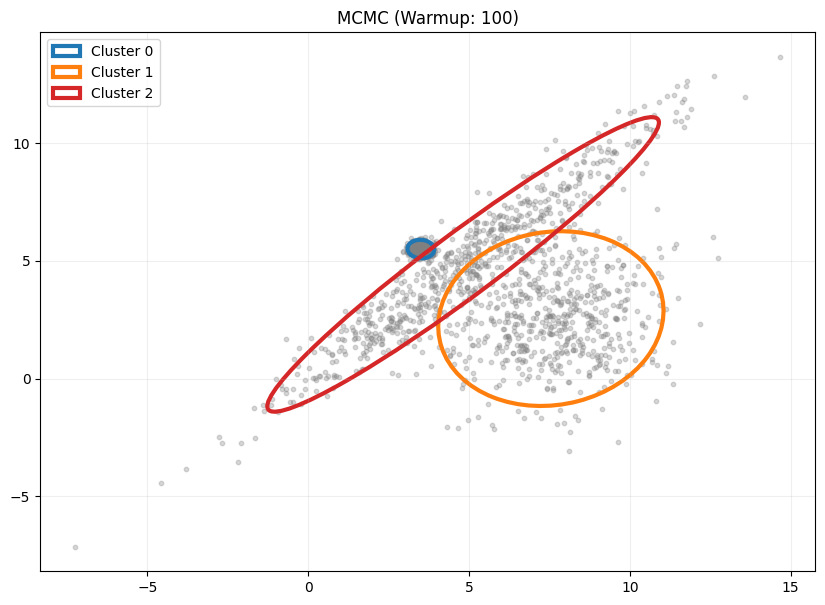

In [108]:
from pyro.infer import MCMC, NUTS
from pyro.infer.autoguide import init_to_median

nuts_kernel_20 = NUTS(model_full, init_strategy=init_to_median)

print("Запуск MCMC (warmup=20)...")
mcmc_20 = MCMC(nuts_kernel_20, num_samples=300, warmup_steps=20)
mcmc_20.run(data_2d)
plot_mcmc_results(data_2d, mcmc_20, "MCMC (Warmup: 20)")

print("Запуск MCMC (warmup=100)...")
nuts_kernel_100 = NUTS(model_full, init_strategy=init_to_median)
mcmc_100 = MCMC(nuts_kernel_100, num_samples=300, warmup_steps=100)
mcmc_100.run(data_2d)
plot_mcmc_results(data_2d, mcmc_100, "MCMC (Warmup: 100)")

Пробую задать initial_params для NUTS на основе KMeans (как альтернативную инициализацию) и проверить влияние на сходимость.
тот же km_centers из 1.1


Запуск MCMC с явной инициализацией...


Sample: 100%|██████████| 400/400 [00:48,  8.24it/s, step size=1.45e-01, acc. prob=0.944]


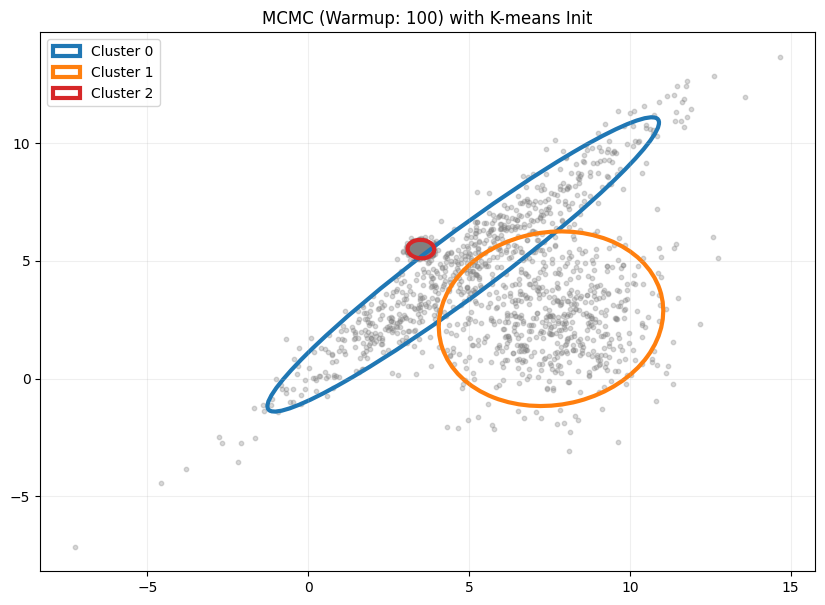

In [109]:
init_params = {
    "locs": km_centers, 
    "weights": torch.ones(3) / 3, 
    "scales": torch.ones(3, 2),    
    "corr_cholesky": torch.eye(2).repeat(3, 1, 1) 
}

from pyro.infer.autoguide import init_to_value

nuts_kernel = NUTS(model_full, init_strategy=init_to_value(values=init_params))
mcmc_100 = MCMC(nuts_kernel, num_samples=300, warmup_steps=100)

print("Запуск MCMC с явной инициализацией...")
mcmc_100.run(data_2d)

plot_mcmc_results(data_2d, mcmc_100, "MCMC (Warmup: 100) with K-means Init")

Задаю sparse GMM (K=10) с Dirichlet(0.1), чтобы смесь сама "выключала" лишние компоненты.


In [110]:
def model_sparse(data, K=10):
    D = data.shape[1]
    weights = pyro.sample("weights", dist.Dirichlet(torch.ones(K) * 0.1))
    
    with pyro.plate("components", K):
        locs = pyro.sample("locs", dist.Normal(torch.zeros(D), 10.).to_event(1))
        scales = pyro.sample("scales", dist.HalfNormal(torch.ones(D)).to_event(1))
        corr_cholesky = pyro.sample("corr_cholesky", dist.LKJCholesky(D, concentration=1.0))
        L_omega = torch.diag_embed(scales) @ corr_cholesky

    mixture = dist.MixtureSameFamily(dist.Categorical(weights), dist.MultivariateNormal(locs, scale_tril=L_omega))
    with pyro.plate("data", len(data)):
        pyro.sample("obs", mixture, obs=data)

pyro.clear_param_store()
guide_sparse = AutoMultivariateNormal(model_sparse, init_loc_fn=init_to_median)
svi = SVI(model_sparse, guide_sparse, pyro.optim.Adam({"lr": 0.01}), loss=Trace_ELBO())

for i in range(2000):
    svi.step(data_2d)

Рисую эллипсы для sparse-модели: компоненты с весом > 0.05 выделяю красным, остальные серым.


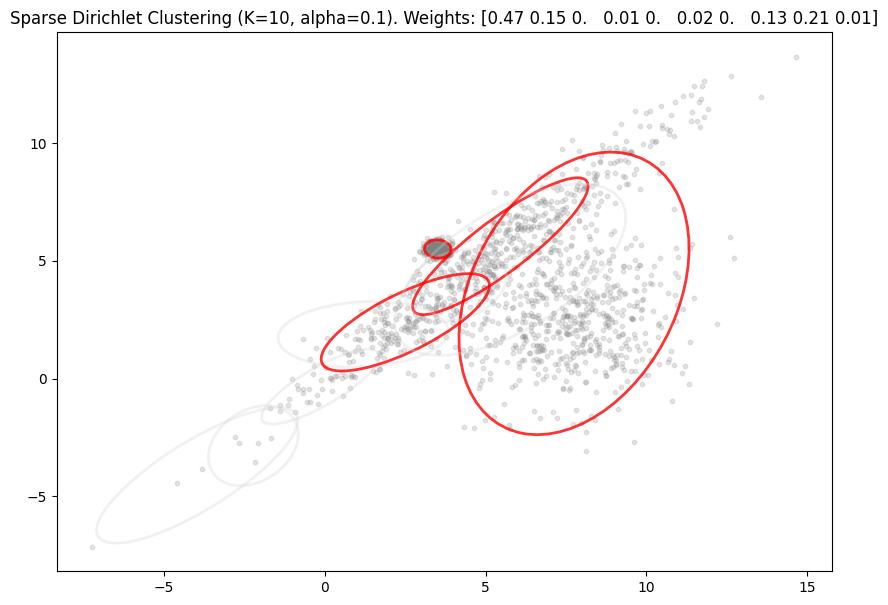

In [111]:
def plot_sparse_results(data, guide):
    with torch.no_grad():
        medians = guide.median()
        locs = medians['locs'].numpy()
        scales = medians['scales'].numpy()
        corr_cholesky = medians['corr_cholesky'].numpy()
        weights = medians['weights'].numpy()
        
    plt.figure(figsize=(10, 7))
    plt.scatter(data[:, 0], data[:, 1], s=10, alpha=0.2, c='gray')
    ax = plt.gca()
    
    for i in range(len(weights)):
        L = np.diag(scales[i]) @ corr_cholesky[i]
        cov = L @ L.T
        vals, vecs = np.linalg.eigh(cov)
        theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
        width, height = 4 * np.sqrt(vals)
        
        color = 'red' if weights[i] > 0.05 else 'lightgray'
        alpha = 0.8 if weights[i] > 0.05 else 0.3
        
        el = Ellipse(xy=locs[i], width=width, height=height, angle=theta,
                     edgecolor=color, fill=False, linewidth=2, alpha=alpha)
        ax.add_patch(el)
    plt.title(f"Sparse Dirichlet Clustering (K=10, alpha=0.1). Weights: {np.round(weights, 2)}")
    plt.show()

plot_sparse_results(data_2d, guide_sparse)

## Автоматизация прогонов (разные seed) + выводы

Основной блок: функции для многократных запусков VI (разные seed), KMeans-init, графики ELBO и эллипсы.


[Basic VI (init_to_median)] seed=0 | steps=2000 | time=8.55s | final_loss=7253.06
[Basic VI (init_to_median)] seed=1 | steps=2000 | time=8.22s | final_loss=7271.91
[Basic VI (init_to_median)] seed=2 | steps=2000 | time=8.24s | final_loss=7247.21


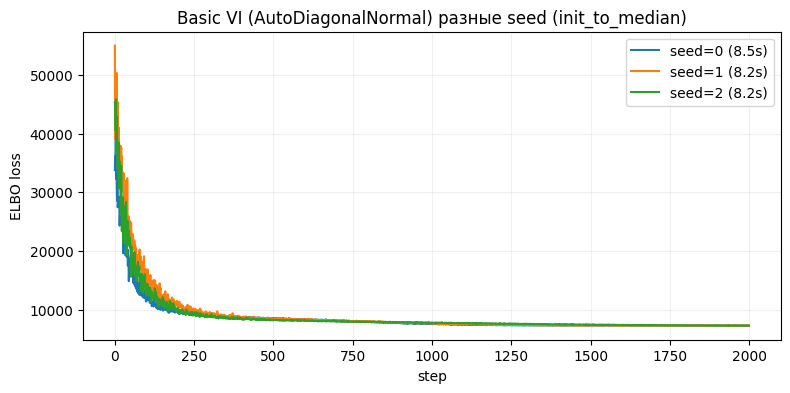

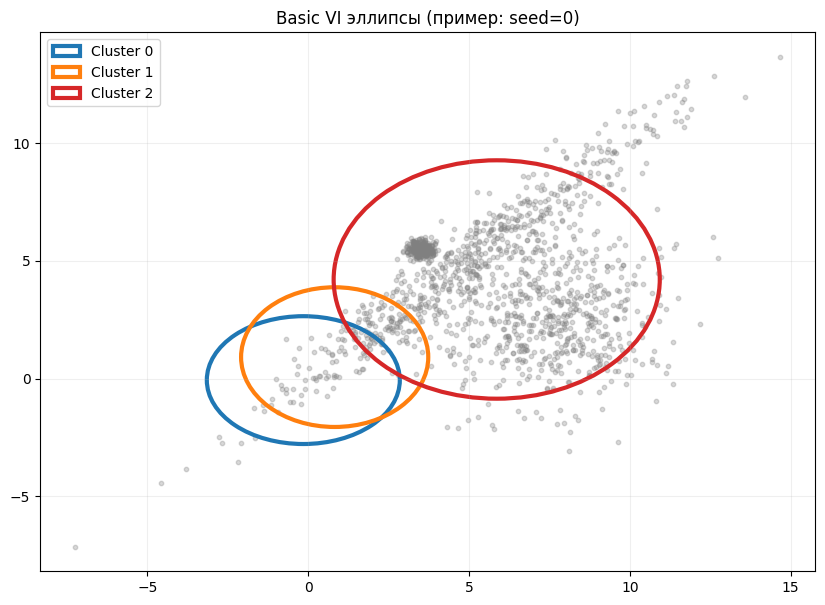

[Basic VI (KMeans init)] seed=0 | steps=2000 | time=8.26s | final_loss=7246.65
[Basic VI (KMeans init)] seed=1 | steps=2000 | time=8.20s | final_loss=7245.07
[Basic VI (KMeans init)] seed=2 | steps=2000 | time=8.17s | final_loss=7247.03


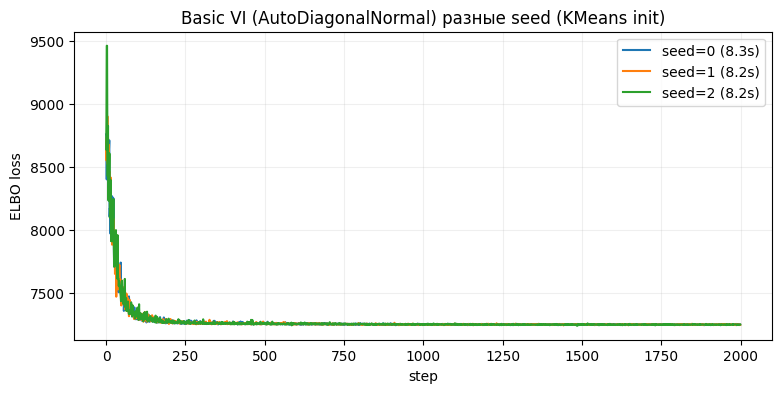

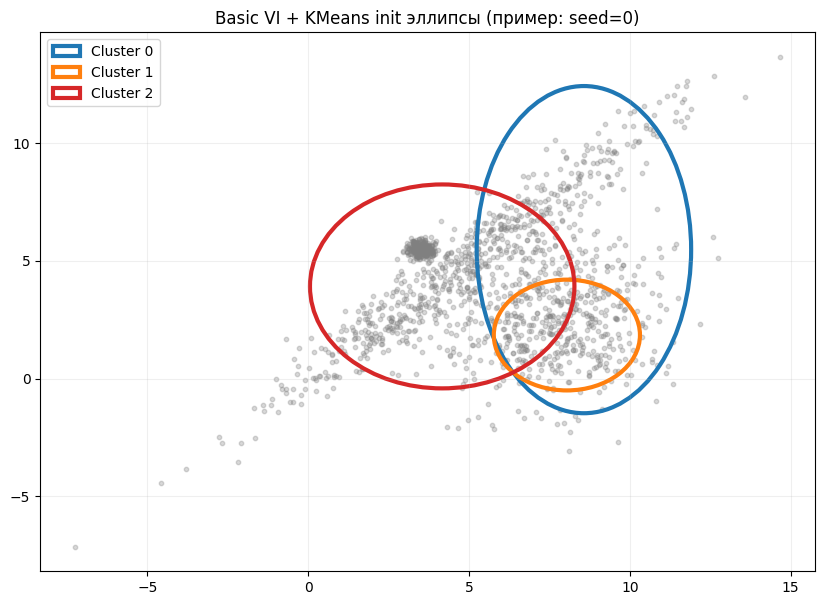

[Full Rank VI (init_to_median)] seed=0 | steps=2000 | time=14.85s | final_loss=7503.75
[Full Rank VI (init_to_median)] seed=1 | steps=2000 | time=14.63s | final_loss=7197.00
[Full Rank VI (init_to_median)] seed=2 | steps=2000 | time=13.91s | final_loss=7514.99


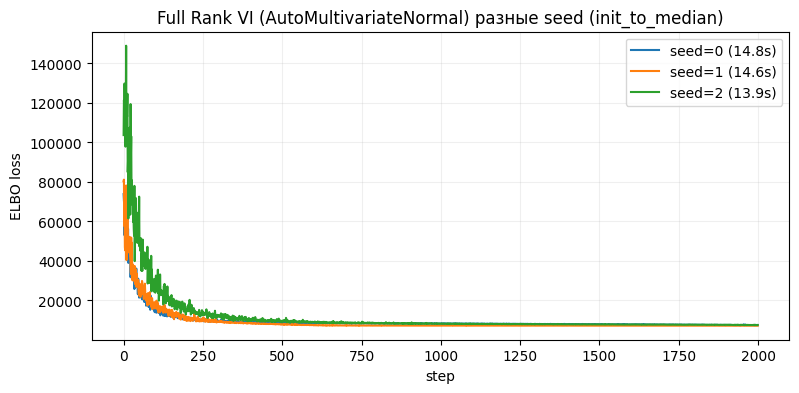

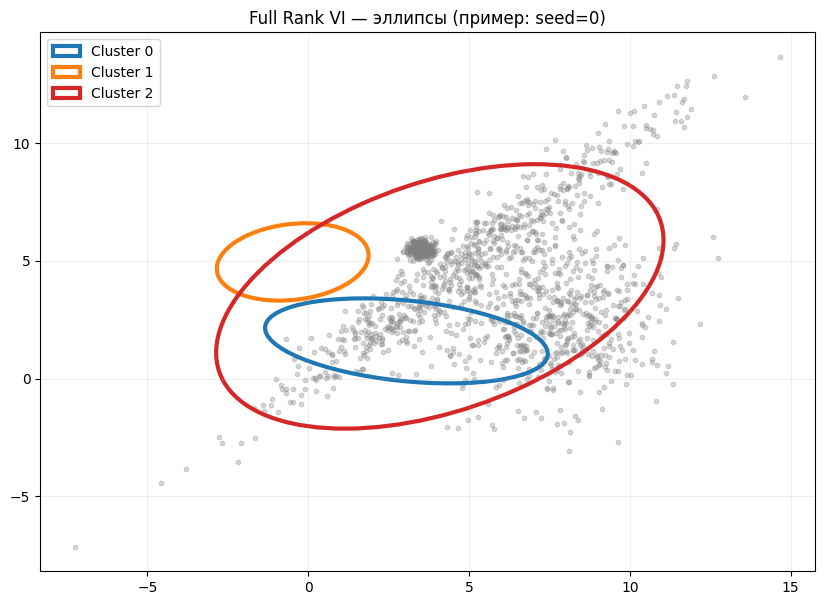

[Full Rank VI (KMeans init)] seed=0 | steps=2000 | time=14.11s | final_loss=6057.95
[Full Rank VI (KMeans init)] seed=1 | steps=2000 | time=13.37s | final_loss=6061.03
[Full Rank VI (KMeans init)] seed=2 | steps=2000 | time=13.44s | final_loss=6057.76


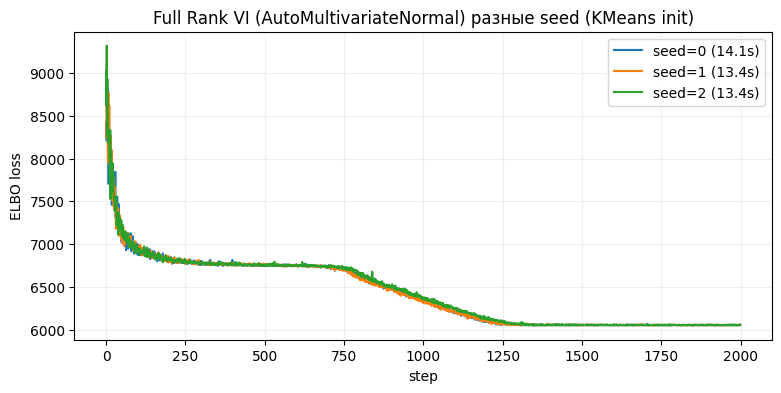

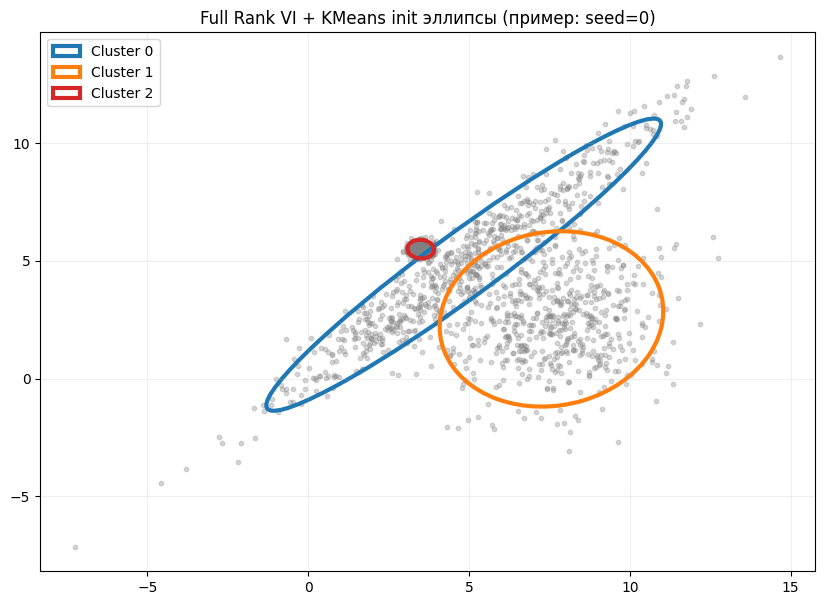

In [112]:
def set_all_seeds(seed: int):
    pyro.set_rng_seed(seed)
    torch.manual_seed(seed)
    np.random.seed(seed)


def run_svi_once(
    *,
    model,
    guide_cls,
    init_loc_fn,
    seed: int,
    data,
    n_steps: int = 2000,
    lr: float = 0.01,
    label: str = "run",
):
    """Запуск одного SVI-прогона + возврат loss, времени и median-параметров."""
    set_all_seeds(seed)
    pyro.clear_param_store()

    guide = guide_cls(model, init_loc_fn=init_loc_fn)
    svi = SVI(model, guide, pyro.optim.Adam({"lr": lr}), loss=Trace_ELBO())

    losses = []
    t0 = time.time()
    for _ in range(n_steps):
        losses.append(svi.step(data))
    dt = time.time() - t0

    with torch.no_grad():
        med = guide.median()

    print(f"[{label}] seed={seed} | steps={n_steps} | time={dt:.2f}s | final_loss={losses[-1]:.2f}")
    return {
        "seed": seed,
        "time": dt,
        "losses": losses,
        "median": med,
    }


def plot_loss_curves(runs, title: str):
    plt.figure(figsize=(9, 4))
    for r in runs:
        plt.plot(r["losses"], label=f"seed={r['seed']} ({r['time']:.1f}s)")
    plt.title(title)
    plt.xlabel("step")
    plt.ylabel("ELBO loss")
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.show()


def plot_diag_ellipses_from_median(data, med, title: str):
    """Для Basic VI: эллипсы без поворота (diag scales)."""
    with torch.no_grad():
        locs = med["locs"].cpu().numpy()
        scales = med["scales"].cpu().numpy()

    plt.figure(figsize=(10, 7))
    plt.scatter(data[:, 0], data[:, 1], s=10, alpha=0.3, c="gray")
    ax = plt.gca()
    colors = ["#1f77b4", "#ff7f0e", "#d62728"]

    for i in range(locs.shape[0]):
        el = Ellipse(
            xy=locs[i],
            width=4 * scales[i, 0],
            height=4 * scales[i, 1],
            angle=0,
            edgecolor=colors[i % len(colors)],
            fill=False,
            linewidth=3,
            label=f"Cluster {i}",
        )
        ax.add_patch(el)

    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()


def plot_full_ellipses_from_median(data, med, title: str):
    """Для Full Rank VI: эллипсы с поворотом (ковариация из L @ L.T)."""
    locs = med["locs"].cpu().numpy()
    scales = med["scales"].cpu().numpy()
    corr_cholesky = med["corr_cholesky"].cpu().numpy()

    plt.figure(figsize=(10, 7))
    plt.scatter(data[:, 0], data[:, 1], s=10, alpha=0.3, c="gray")
    ax = plt.gca()
    colors = ["#1f77b4", "#ff7f0e", "#d62728"]

    for i in range(locs.shape[0]):
        L = np.diag(scales[i]) @ corr_cholesky[i]
        cov = L @ L.T
        vals, vecs = np.linalg.eigh(cov)
        order = vals.argsort()[::-1]
        vals, vecs = vals[order], vecs[:, order]
        theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
        width, height = 4 * np.sqrt(vals)

        el = Ellipse(
            xy=locs[i],
            width=width,
            height=height,
            angle=theta,
            edgecolor=colors[i % len(colors)],
            fill=False,
            linewidth=3,
            label=f"Cluster {i}",
        )
        ax.add_patch(el)

    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()



def make_kmeans_init_fn(data, K: int):
    km = KMeans(n_clusters=K, n_init=10, random_state=0).fit(data.detach().cpu().numpy())
    centers = torch.tensor(km.cluster_centers_, dtype=torch.float)

    def init_loc_fn(site):
        if site["name"] == "locs":
            return centers
        if site["name"] == "scales":
            shape = site["fn"].batch_shape + site["fn"].event_shape
            return torch.ones(shape, device=centers.device)
        return init_to_median(site)

    return init_loc_fn



basic_seeds = [0, 1, 2]

runs_basic_default = [
    run_svi_once(
        model=model_mf,
        guide_cls=AutoDiagonalNormal,
        init_loc_fn=init_to_median,
        seed=s,
        data=data_2d,
        label="Basic VI (init_to_median)",
    )
    for s in basic_seeds
]
plot_loss_curves(runs_basic_default, "Basic VI (AutoDiagonalNormal) разные seed (init_to_median)")
plot_diag_ellipses_from_median(data_2d.numpy(), runs_basic_default[0]["median"], "Basic VI эллипсы (пример: seed=0)")

init_loc_fn_km_basic = make_kmeans_init_fn(data_2d, K=3)

runs_basic_km = [
    run_svi_once(
        model=model_mf,
        guide_cls=AutoDiagonalNormal,
        init_loc_fn=init_loc_fn_km_basic,
        seed=s,
        data=data_2d,
        label="Basic VI (KMeans init)",
    )
    for s in basic_seeds
]
plot_loss_curves(runs_basic_km, "Basic VI (AutoDiagonalNormal) разные seed (KMeans init)")
plot_diag_ellipses_from_median(data_2d.numpy(), runs_basic_km[0]["median"], "Basic VI + KMeans init эллипсы (пример: seed=0)")


full_seeds = [0, 1, 2]

runs_full_default = [
    run_svi_once(
        model=model_full,
        guide_cls=AutoMultivariateNormal,
        init_loc_fn=init_to_median,
        seed=s,
        data=data_2d,
        label="Full Rank VI (init_to_median)",
    )
    for s in full_seeds
]
plot_loss_curves(runs_full_default, "Full Rank VI (AutoMultivariateNormal) разные seed (init_to_median)")
plot_full_ellipses_from_median(data_2d.numpy(), runs_full_default[0]["median"], "Full Rank VI — эллипсы (пример: seed=0)")

init_loc_fn_km_full = make_kmeans_init_fn(data_2d, K=3)

runs_full_km = [
    run_svi_once(
        model=model_full,
        guide_cls=AutoMultivariateNormal,
        init_loc_fn=init_loc_fn_km_full,
        seed=s,
        data=data_2d,
        label="Full Rank VI (KMeans init)",
    )
    for s in full_seeds
]
plot_loss_curves(runs_full_km, "Full Rank VI (AutoMultivariateNormal) разные seed (KMeans init)")
plot_full_ellipses_from_median(data_2d.numpy(), runs_full_km[0]["median"], "Full Rank VI + KMeans init эллипсы (пример: seed=0)")

## Результат

Почему Basic VI (диагональная ковариация) может быть неадекватен:
 если настоящий кластер вытянут/повёрнут (корреляция между осями), диагональная модель не умеет повернуть эллипс и вынуждена либо делать его толстым, либо промахиваться по форме.
Почему Full Rank VI лучше описывает данные
полная ковариация (через LKJCholesky) позволяет поворот эллипсов (ненулевая корреляция), поэтому вытянутые кластеры описываются реалистичнее.
цена
Full Rank VI оптимизирует больше параметров обычно дольше и может быть менее стабильным по seed.
KMeans-инициализация
как эмпирический Байес помогает задать старт в разумной области и уменьшает риск плохого локального минимума VI.

Адекватность на данных
Для кластера B (вытянутого по диагонали) Basic VI хуже, Full Rank должен давать заметно лучшее совпадение формы.

Сравниваю MCMC/NUTS при warmup=20 и warmup=100: измеряю время и смотрю ArviZ-диагностики (trace, R-hat, autocorr) + эллипсы.


In [ ]:
def run_mcmc_with_diagnostics(*, model, data, warmup: int, num_samples: int = 300, num_chains: int = 2, label: str = "MCMC"):
    set_all_seeds(0)

    # NUTS/MCMC чаще быстрее и стабильнее на CPU, и так прогресс отображается лучше
    data_cpu = data.detach().cpu() if isinstance(data, torch.Tensor) else data

    nuts = NUTS(model, init_strategy=init_to_median)
    mcmc = MCMC(
        nuts,
        num_samples=num_samples,
        warmup_steps=warmup,
        num_chains=num_chains,
        disable_progbar=False,
    )

    t0 = time.time()
    mcmc.run(data_cpu)
    dt = time.time() - t0

    print(f"[{label}] warmup={warmup}, samples={num_samples}, chains={num_chains} | time={dt:.2f}s")

    data_az = az.from_pyro(mcmc)
    print(az.summary(data_az, var_names=["weights", "locs"], round_to=2))
    az.plot_trace(data_az, var_names=["weights", "locs"])
    az.plot_autocorr(data_az, var_names=["locs"], combined=True)

    plot_mcmc_results(data_2d.numpy(), mcmc, f"{label} (warmup={warmup}, time={dt:.1f}s)")

    return mcmc, dt

mcmc20, t20 = run_mcmc_with_diagnostics(model=model_full, data=data_2d, warmup=20, label="NUTS Full model")
mcmc100, t100 = run_mcmc_with_diagnostics(model=model_full, data=data_2d, warmup=100, label="NUTS Full model")

Warmup [1]:   0%|          | 0/320 [00:00, ?it/s]

Warmup [2]:   0%|          | 0/320 [00:00, ?it/s]

Запускаю NUTS на sparse-модели (K=10, alpha=0.1), чтобы показать, почему MCMC становится ещё медленнее при избыточных компонентах.
K=10, alpha=0.1: NUTS на разреженной модели (для сравнения с Full Rank VI)


In [ ]:
def run_sparse_nuts(*, warmup: int = 100, num_samples: int = 300, num_chains: int = 2):
    nuts = NUTS(model_sparse, init_strategy=init_to_median)
    mcmc = MCMC(nuts, num_samples=num_samples, warmup_steps=warmup, num_chains=num_chains)

    t0 = time.time()
    mcmc.run(data_2d)
    dt = time.time() - t0

    print(f"[NUTS sparse] warmup={warmup}, samples={num_samples}, chains={num_chains} | time={dt:.2f}s")

    data_az = az.from_pyro(mcmc)
    print(az.summary(data_az, var_names=["weights"], round_to=3))
    az.plot_trace(data_az, var_names=["weights"])
    return mcmc, dt


Почему VI быстрее MCMC, но может смещать дисперсию? VI выигрывает в скорости, так как заменяет сложное сэмплирование задачей оптимизации, позволяя использовать быстрые градиентные шаги и проходы по мини-батчам, тогда как MCMC требует огромных вычислений для построения длинных цепочек сэмплов. Однако при минимизации вариационное приближение штрафуется за попадание в области низкой плотности истинного постериора, из-за чего оно часто становится слишком «узким» и недооценивает неопределенность.
«Честно» ли инициализировать байесовскую модель через K-means? Если K-means используется только как вычислительная помощь для быстрого попадания в разумную область параметров, не подменяя саму вероятностную модель. Но это не является чистым байесовским выводом, так как это детерминированная процедура на основе данных, такой подход становится нечестным, если результаты K-means фактически фиксируют параметры или выдаются за результат без оговорок об использовании данных для инициализации.
Как sparsity prior Dirichlet помогает автоматически определить число кластеров? Использование разреживающего распределения Дирихле с параметром заставляет модель поощрять ситуацию, когда веса лишь нескольких компонент значительны, а остальные стремятся к нулю. Это позволяет задать количество кластеров «с запасом», после чего в процессе обучения лишние компоненты автоматически «выключаются», и эффективное число групп определяется просто по количеству активных участников с весом выше порога.